In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
df = pd.read_csv('spam.csv', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [58]:
# Data cleaning
# EDA
# Text preprocessing
# Model building
# Evaluation
# Deployment

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [60]:
df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True)

In [61]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [62]:
df.rename(columns={'v1': 'label', 'v2': 'message'}, inplace=True)
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [63]:
df.duplicated().sum()

np.int64(403)

In [64]:
df.drop_duplicates(inplace=True)

In [65]:
df = pd.get_dummies(df, columns=['label'], drop_first=True)

In [66]:
df.head()

,message,label_spam
0,"Go until jurong point, crazy.. Available only ...",False
1,Ok lar... Joking wif u oni...,False
2,Free entry in 2 a wkly comp to win FA Cup fina...,True
3,U dun say so early hor... U c already then say...,False
4,"Nah I don't think he goes to usf, he lives aro...",False


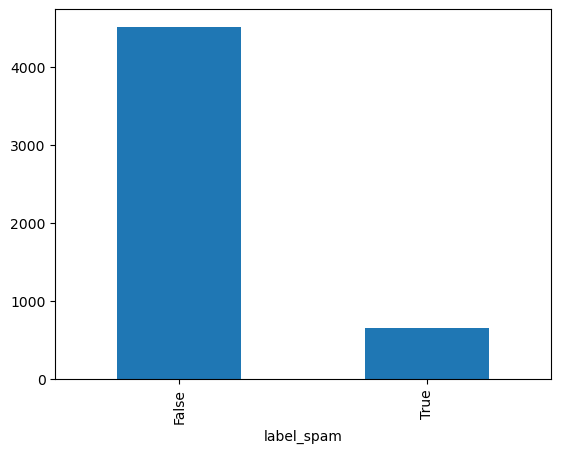

In [67]:
df['label_spam'].value_counts().plot(kind='bar')
plt.show()

In [68]:
#The Data is imbalanced. We will use undersampling to balance the data.

In [69]:
!pip install nltk


In [70]:
import nltk

In [71]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\arije\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [72]:
df['num_characters'] = df['message'].apply(len)
#no of characters in the message

In [73]:
df['num_words'] = df['message'].apply(lambda x: len(nltk.word_tokenize(x)))

In [74]:
df.head()

,message,label_spam,num_characters,num_words
0,"Go until jurong point, crazy.. Available only ...",False,111,24
1,Ok lar... Joking wif u oni...,False,29,8
2,Free entry in 2 a wkly comp to win FA Cup fina...,True,155,37
3,U dun say so early hor... U c already then say...,False,49,13
4,"Nah I don't think he goes to usf, he lives aro...",False,61,15


In [75]:
df['num_sentences'] = df['message'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [76]:
df.head()

,message,label_spam,num_characters,num_words,num_sentences
0,"Go until jurong point, crazy.. Available only ...",False,111,24,2
1,Ok lar... Joking wif u oni...,False,29,8,2
2,Free entry in 2 a wkly comp to win FA Cup fina...,True,155,37,2
3,U dun say so early hor... U c already then say...,False,49,13,1
4,"Nah I don't think he goes to usf, he lives aro...",False,61,15,1


<Axes: xlabel='num_characters', ylabel='Count'>

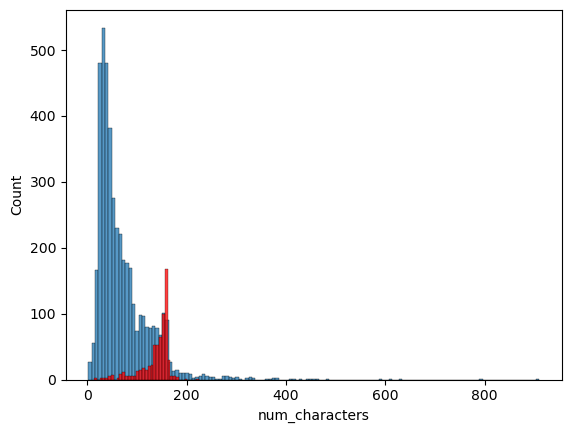

In [77]:
sns.histplot(df[df['label_spam'] == 0]['num_characters'])
sns.histplot(df[df['label_spam'] == 1]['num_characters'], color='red')

Data Preprocessing
1. Lower Case
2. Tokenize
3. Removing Special Characters
4. Removing Stop Words and Punctuation
5. Stemming

In [78]:
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [79]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [82]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [84]:
def transform_text(text):
    text=  text.lower()
    text = nltk.word_tokenize(text)
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)   

    text = y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))  
    return " ".join(y)

In [86]:
df['transformed_text'] = df['message'].apply(transform_text)

In [87]:
df.head(1)

,message,label_spam,num_characters,num_words,num_sentences,transformed_text
0,"Go until jurong point, crazy.. Available only ...",False,111,24,2,go jurong point crazi avail bugi n great world...


Text Vectorization
#bag of words

In [88]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()

In [89]:
x = cv.fit_transform(df['transformed_text']).toarray()

In [90]:
x.shape

(5169, 6708)

In [91]:
y = df['label_spam'].values

In [92]:
y

array([False, False,  True, ..., False, False, False], shape=(5169,))

In [93]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

In [94]:
from sklearn.naive_bayes import MultinomialNB, GaussianNB, BernoulliNB
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [95]:
gnb.fit(x_train, y_train)
y_pred1 = gnb.predict(x_test)

In [96]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [99]:
print(accuracy_score(y_test, y_pred1))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred1))
print("Precision Score:", precision_score(y_test, y_pred1))

0.8800773694390716
Confusion Matrix:
 [[792 104]
 [ 20 118]]
Precision Score: 0.5315315315315315


In [100]:
mnb.fit(x_train, y_train)
y_pred2 = mnb.predict(x_test)
print(accuracy_score(y_test, y_pred2))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred2))
print("Precision Score:", precision_score(y_test, y_pred2))

0.9642166344294004
Confusion Matrix:
 [[871  25]
 [ 12 126]]
Precision Score: 0.8344370860927153


In [101]:
bnb.fit(x_train, y_train)
y_pred3 = bnb.predict(x_test)
print(accuracy_score(y_test, y_pred3))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred3))
print("Precision Score:", precision_score(y_test, y_pred3))

0.9700193423597679
Confusion Matrix:
 [[893   3]
 [ 28 110]]
Precision Score: 0.9734513274336283


In [103]:
import pickle
pickle.dump(cv, open('vectorizer.pkl', 'wb'))
pickle.dump(bnb, open('bnb_model.pkl', 'wb'))